# MMFDB · External tools in the provenance graph

A provenance system is only useful if it can record work done by **any** tool —
not just ChiSurf. This example takes one measurement stored in **MMFDB** and
processes it with two *external* tools:

1. a **command-line script** built on vanilla `tttrlib` (run as a real
   subprocess — `external_tools/fret_burst_tool.py`), and
2. **FRETBursts**, a third-party single-molecule FRET Python package.

Each run is recorded as a provenance **operation** — with the tool's name,
version, command line, parameters, and checksummed input/output artifacts — so
the lineage `raw → tool → result` is queryable afterwards. We simulate the input
so the ground-truth FRET is known and both tools can be checked against it.

In [1]:
%matplotlib inline
import logging, warnings, io, contextlib, hashlib, json, subprocess, sys, tempfile
import datetime as dt
from pathlib import Path
for _n in ("numexpr", "mmfdb"):
    logging.getLogger(_n).setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
# FRETBursts 0.8.3 predates NumPy 2; restore the one symbol it needs.
if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)
import tttrlib
from chisurf.plugins.burst.burst_analysis.api import BurstWorkflow

# FRETBursts ships C extensions built for NumPy 1.x; import it once with all
# stdout/stderr silenced (it falls back to a pure-Python burst search).
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    import fretbursts as fb
    from fretbursts import loader

TOOL = Path("external_tools/fret_burst_tool.py").resolve()
def sha256(p):
    return hashlib.sha256(Path(p).read_bytes()).hexdigest()

## 1. Put a measurement in MMFDB

We simulate a two-state smFRET dataset (E = 0.25 / 0.75), store it, and register
the raw file as a provenance **artifact** — the shared input both tools consume.

In [2]:
wf = BurstWorkflow.demo()
client = wf._client                      # the raw MMFDB client, for provenance calls

sim = wf.simulate(fret=(0.25, 0.75), exchange_rate=2.0, background=0.5, n_photons=900_000)
raw = wf.fetch(sim.handle)
raw_id = f"raw/{sim.handle}"
client.call("mmfdb.v1.artifacts.register", {
    "artifact_id": raw_id, "artifact_kind": "raw_measurement", "file_path": str(raw),
    "checksum": sha256(raw), "size_bytes": raw.stat().st_size,
    "metadata": {"object_uuid": sim.handle, "simulated": True}})
print("raw artifact:", raw_id)
print("ground-truth FRET:", sim.truth.fret.tolist())

raw artifact: raw/11939508-c3b6-43e6-8c2a-3e789552d43e
ground-truth FRET: [0.25, 0.75]


A small helper records one external-tool run: it registers the output artifact
and links `raw → operation → output`, storing the tool name/version, the exact
command line, and typed parameters.

In [3]:
def record_tool_run(op_id, software, version, command_line, params, out_id, out_path,
                    started, ended, extra_settings=None):
    return client.call("mmfdb.v1.operations.record_with_artifacts", {
        "operation_id": op_id, "operation_type": "burst_selection", "status": "succeeded",
        "software_package": software, "software_version": version,
        "started_at": started, "ended_at": ended,
        "settings": {"command_line": command_line, **(extra_settings or {})},
        "input_artifacts": [{"artifact_id": raw_id, "artifact_kind": "raw_measurement",
                             "file_path": str(raw), "checksum": sha256(raw), "role": "raw_photons"}],
        "output_artifacts": [{"artifact_id": out_id, "artifact_kind": "burst_table",
                              "file_path": str(out_path), "checksum": sha256(out_path), "role": "bursts"}],
        "parameters": [{"parameter_uuid": f"{op_id}/{k}", "name": k, "value": v}
                       for k, v in params.items()],
    })

## 2. Tool 1 — a vanilla-`tttrlib` CLI, run as a subprocess

`fret_burst_tool.py` knows nothing about ChiSurf or MMFDB. We fetch the file,
invoke the tool as a real subprocess, and capture its command line, exit code,
and JSON result.

In [4]:
out_cli = raw.parent / "bursts_cli.csv"
argv = [sys.executable, str(TOOL), str(raw), "--file-type", "SPC-130",
        "--min-photons", "20", "--background-cps", "500", "--output", str(out_cli)]

started = dt.datetime.now(dt.timezone.utc).isoformat()
proc = subprocess.run(argv, capture_output=True, text=True)
ended = dt.datetime.now(dt.timezone.utc).isoformat()
summary = json.loads(proc.stdout)
print("exit code:", proc.returncode)
print(summary["n_bursts"], "bursts, mean E =", round(summary["mean_proximity_ratio"], 3))

exit code: 0
3579 bursts, mean E = 0.502


Record the subprocess run in the provenance graph:

In [5]:
r1 = record_tool_run(
    f"op/cli/{sim.handle}", "fret_burst_tool", summary["backend"],
    " ".join(argv[1:]), {"min_photons": 20, "signal_to_background_ratio": 4.0},
    f"bursts/cli/{sim.handle}", out_cli, started, ended,
    extra_settings={"exit_code": proc.returncode})
print("recorded:", {k: v for k, v in r1.items() if 'count' in k})

recorded: {'input_count': 0, 'output_count': 1, 'parameter_count': 2, 'input_link_count': 1, 'output_link_count': 1}


## 3. Tool 2 — FRETBursts (third-party package)

[FRETBursts](https://fretbursts.readthedocs.io) reads Photon-HDF5, so we export
the fetched photons to that interchange format and run its burst search. (It
predates NumPy 2, hence the one-line `np.asfarray` shim above.)

In [6]:
import phconvert as phc
tttr = tttrlib.TTTR(str(raw), "SPC-130")
macro = np.asarray(tttr.macro_times).astype("int64")
det = np.asarray(tttr.routing_channels).astype("uint8")
res = float(tttr.header.macro_time_resolution); total = macro[-1] * res
h5 = raw.parent / "for_fretbursts.hdf5"
phc.hdf5.save_photon_hdf5(dict(
    description="simulated smFRET", identity=dict(author="sim"),
    setup=dict(num_pixels=2, num_spots=1, num_spectral_ch=2, num_polarization_ch=1,
               num_split_ch=1, modulated_excitation=False, lifetime=False,
               excitation_alternated=[False], excitation_cw=[True],
               excitation_wavelengths=[532e-9], detection_wavelengths=[580e-9, 640e-9]),
    photon_data=dict(timestamps=macro, detectors=det,
        timestamps_specs=dict(timestamps_unit=res),
        measurement_specs=dict(measurement_type="smFRET",
            detectors_specs=dict(spectral_ch1=np.array([0], "uint8"),
                                 spectral_ch2=np.array([1], "uint8"))))),
    h5_fname=str(h5), overwrite=True)

started = dt.datetime.now(dt.timezone.utc).isoformat()
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    d = loader.photon_hdf5(str(h5))
    d.calc_bg(fb.bg.exp_fit, time_s=max(total / 3, 1.0), tail_min_us=200)
    d.burst_search(F=6, m=10)
    ds = d.select_bursts(fb.select_bursts.size, th1=20)
ended = dt.datetime.now(dt.timezone.utc).isoformat()
E_fb = np.asarray(ds.E[0]); out_fb = raw.parent / "bursts_fretbursts.csv"
np.savetxt(out_fb, E_fb, header="E", comments="")
print(f"FRETBursts {fb.__version__}:", int(ds.num_bursts[0]), "bursts, mean E =", round(float(np.nanmean(E_fb)), 3))

Saving: /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/burst_wf_qpcirr2l/for_fretbursts.hdf5


FRETBursts 0.8.3: 2647 bursts, mean E = 0.504


In [7]:
r2 = record_tool_run(
    f"op/fretbursts/{sim.handle}", "FRETBursts", fb.__version__,
    "loader.photon_hdf5 -> calc_bg(exp_fit) -> burst_search(F=6, m=10) -> select_bursts(size>20)",
    {"F": 6, "m": 10, "size_threshold": 20},
    f"bursts/fb/{sim.handle}", out_fb, started, ended)
print("recorded:", {k: v for k, v in r2.items() if 'count' in k})

recorded: {'input_count': 0, 'output_count': 1, 'parameter_count': 3, 'input_link_count': 1, 'output_link_count': 1}


## 4. Query the provenance graph

Both tools now hang off the same raw artifact. We ask MMFDB for everything
**downstream** of the raw measurement and draw the lineage.

In [8]:
down = client.call("provenance.dependencies.downstream", {"node_type": "artifact", "node_id": raw_id})
for e in down["edges"]:
    print(f"  {e['source_node_id'].split('/')[0]:8s} --{e['relationship_type']}--> {e['target_node_id']}")

  raw      --input_to--> op/cli/11939508-c3b6-43e6-8c2a-3e789552d43e
  raw      --input_to--> op/fretbursts/11939508-c3b6-43e6-8c2a-3e789552d43e
  op       --produced--> bursts/cli/11939508-c3b6-43e6-8c2a-3e789552d43e
  op       --produced--> bursts/fb/11939508-c3b6-43e6-8c2a-3e789552d43e


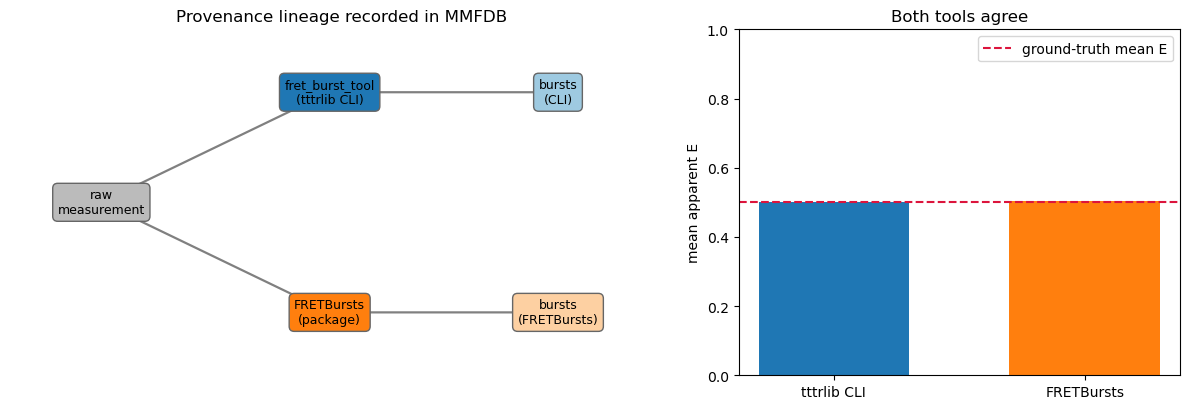

In [9]:
# Lineage DAG + a check of both tools against the ground truth
fig, (axg, axb) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [3, 2]})

pos = {"raw": (0, 0.5), "cli": (1, 0.85), "fb": (1, 0.15),
       "out_cli": (2, 0.85), "out_fb": (2, 0.15)}
labels = {"raw": "raw\nmeasurement", "cli": "fret_burst_tool\n(tttrlib CLI)",
          "fb": "FRETBursts\n(package)", "out_cli": "bursts\n(CLI)", "out_fb": "bursts\n(FRETBursts)"}
colors = {"raw": "#bbbbbb", "cli": "#1f77b4", "fb": "#ff7f0e", "out_cli": "#9ecae1", "out_fb": "#fdd0a2"}
for a, b in [("raw", "cli"), ("raw", "fb"), ("cli", "out_cli"), ("fb", "out_fb")]:
    axg.annotate("", xy=pos[b], xytext=pos[a], arrowprops=dict(arrowstyle="->", lw=1.6, color="0.5"))
for k, (x, y) in pos.items():
    axg.text(x, y, labels[k], ha="center", va="center", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", fc=colors[k], ec="0.4"))
axg.set_xlim(-0.4, 2.5); axg.set_ylim(-0.05, 1.05); axg.axis("off")
axg.set_title("Provenance lineage recorded in MMFDB")

means = [float(summary["mean_proximity_ratio"]), float(np.nanmean(E_fb))]
axb.bar(["tttrlib CLI", "FRETBursts"], means, color=["#1f77b4", "#ff7f0e"], width=0.6)
axb.axhline(float(np.mean(sim.truth.fret)), color="crimson", ls="--", label="ground-truth mean E")
axb.set_ylim(0, 1); axb.set_ylabel("mean apparent E"); axb.set_title("Both tools agree")
axb.legend()
fig.tight_layout(); plt.show()

## 5. What MMFDB records well — and the gaps

**Works today:** any external tool can be a first-class provenance operation —
tool name (`software_package`), version, timestamps, typed parameters, and
checksummed input/output artifacts, all queryable as a lineage DAG.

**Gaps we hit (filed in the project backlog):**

- **No command-line / exit-code columns** — we had to bury `command_line` and
  `exit_code` inside the free-form `settings` JSON, so they are unqueryable.
- **No generic `external_tool` operation type** — we reused `burst_selection`;
  the constrained vocabulary has no `external_tool` / `cli` value, and the two
  record paths validate the type inconsistently (static enum vs extensible DB).
- **No software-vs-human actor distinction**, and **no container/environment**
  schema (image + digest) for true reproducibility.

The vanilla-`tttrlib` tool lives in `external_tools/fret_burst_tool.py` and can
be run entirely on its own.

In [10]:
wf.close()
print("Finished.")

Finished.
